# spatial neighbourhoods

In [1]:
import warnings
warnings.filterwarnings('ignore')
import scanpy as sc
import matplotlib.pyplot as plt 
import numpy as np
def spatial_neigbourshoods(anndata,
                           cluster_label = 'leiden_0.5',
                           max_distance_allowed = 200):
    
    import numpy as np
    import scanpy as sc
    import pandas as pd
    from sklearn.metrics.pairwise import euclidean_distances
    
    distances_input=np.array([anndata.obs['x_centroid'],anndata.obs['y_centroid']])
    din=distances_input.transpose()
    distances=euclidean_distances(din, din)
    dist_df=pd.DataFrame(distances)
    max_distance_allowed=max_distance_allowed
    dist_binary=((dist_df<max_distance_allowed)*1)*((dist_df!=
                                                     0)*1)
    np.sum(np.sum(dist_binary))
    dist_binary['name']=list(anndata.obs[cluster_label])
    distbinsum=dist_binary.groupby('name').sum()
    adata=sc.AnnData(distbinsum.transpose())
    adata.obs=anndata.obs

    return adata


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

# run spatial neigbourshoods

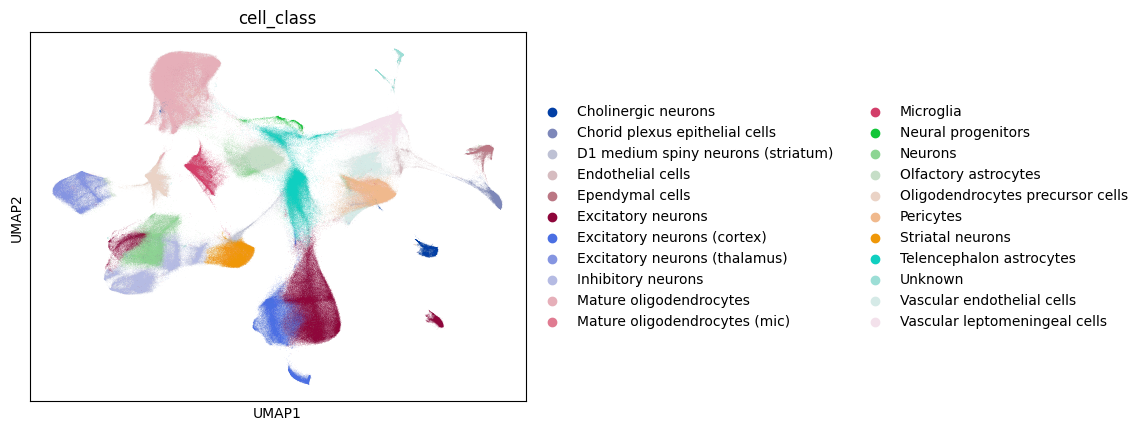

In [3]:
sc.pl.umap(adata, color = 'cell_class')

In [4]:
adata.obs.sample_id.unique()

['RB4282', 'RB4350', 'RB4401', 'RB4403', 'RB4405', ..., 'RB4627', 'RB4630', 'RB4653', 'RB4658', 'RB4676']
Length: 12
Categories (12, object): ['RB4282', 'RB4350', 'RB4401', 'RB4403', ..., 'RB4630', 'RB4653', 'RB4658', 'RB4676']

In [5]:
ad_sn_list = []
for i in ['RB4405']:
    print(i)
    ad_sub_sample = adata[adata.obs['sample_id'] == i]
    ad_sn = spatial_neigbourshoods(anndata = ad_sub_sample, cluster_label = 'cell_class',max_distance_allowed = 500) #50 #600 #200#550
    ad_sn_list.append(ad_sn)

RB4405


In [11]:
ad_sn = sc.concat(ad_sn_list, join = 'outer', fill_value = 0)

In [12]:
spatial = np.array(ad_sn.obs[['x_centroid','y_centroid']])
ad_sn.obsm['spatial'] = spatial

In [13]:
sc.pp.neighbors(ad_sn, n_neighbors=10)
sc.tl.umap(ad_sn,min_dist=0.2)

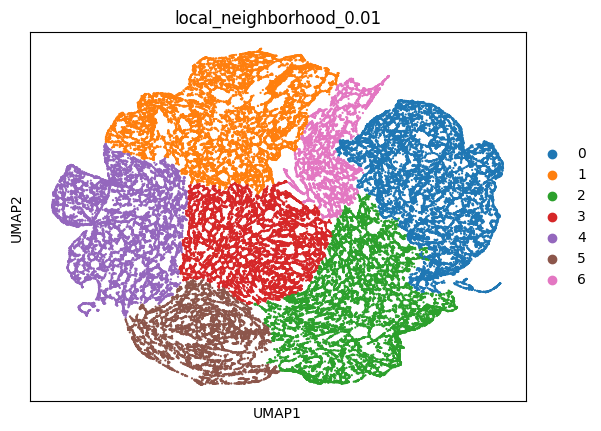

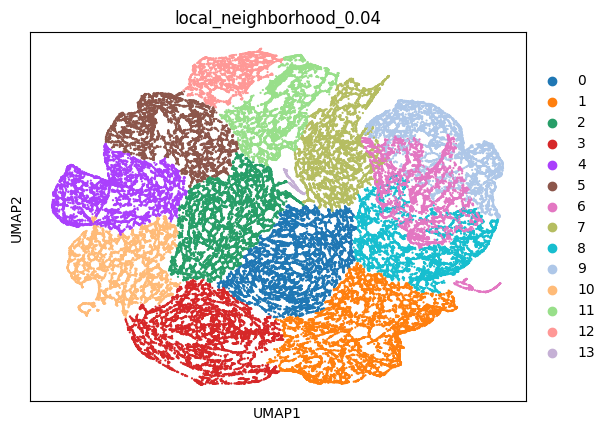

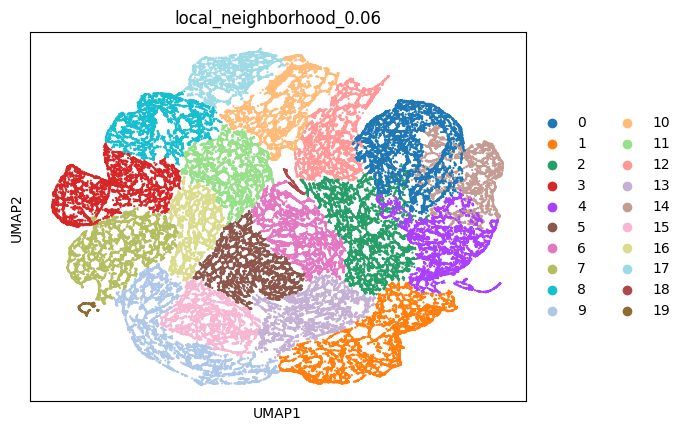

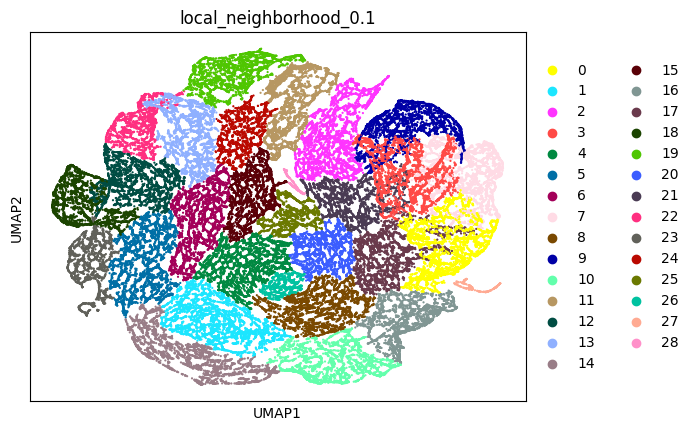

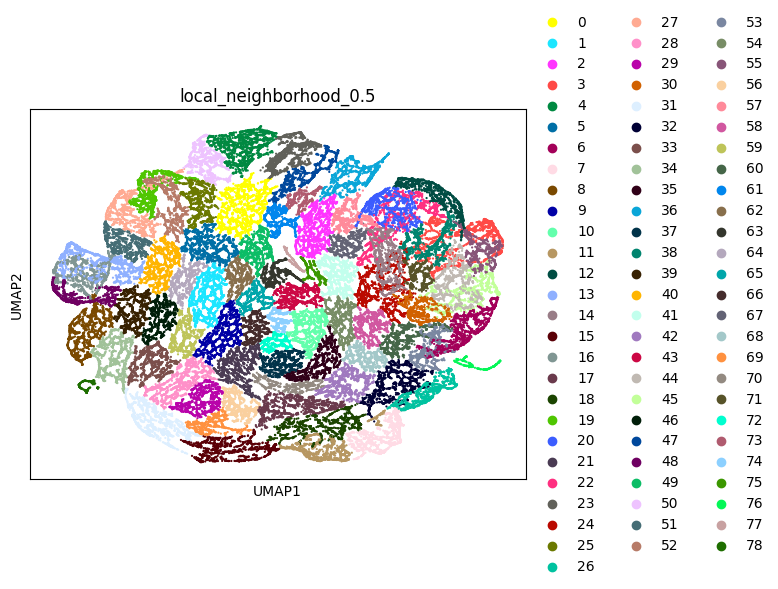

In [14]:
for i in [0.01,  0.04, 0.06,0.1,0.5]: 
    key = 'local_neighborhood_'+str(i)
    if key in ad_sn.obs.columns: 
        sc.pl.umap(ad_sn,color=[key],  s = 10)#,save='UMAP_10X_colors.svg')
    else: 
        sc.tl.leiden(ad_sn,resolution=i, key_added = key)
        sc.pl.umap(ad_sn,color=[key],  s = 10)#,save='UMAP_10X_colors.svg')

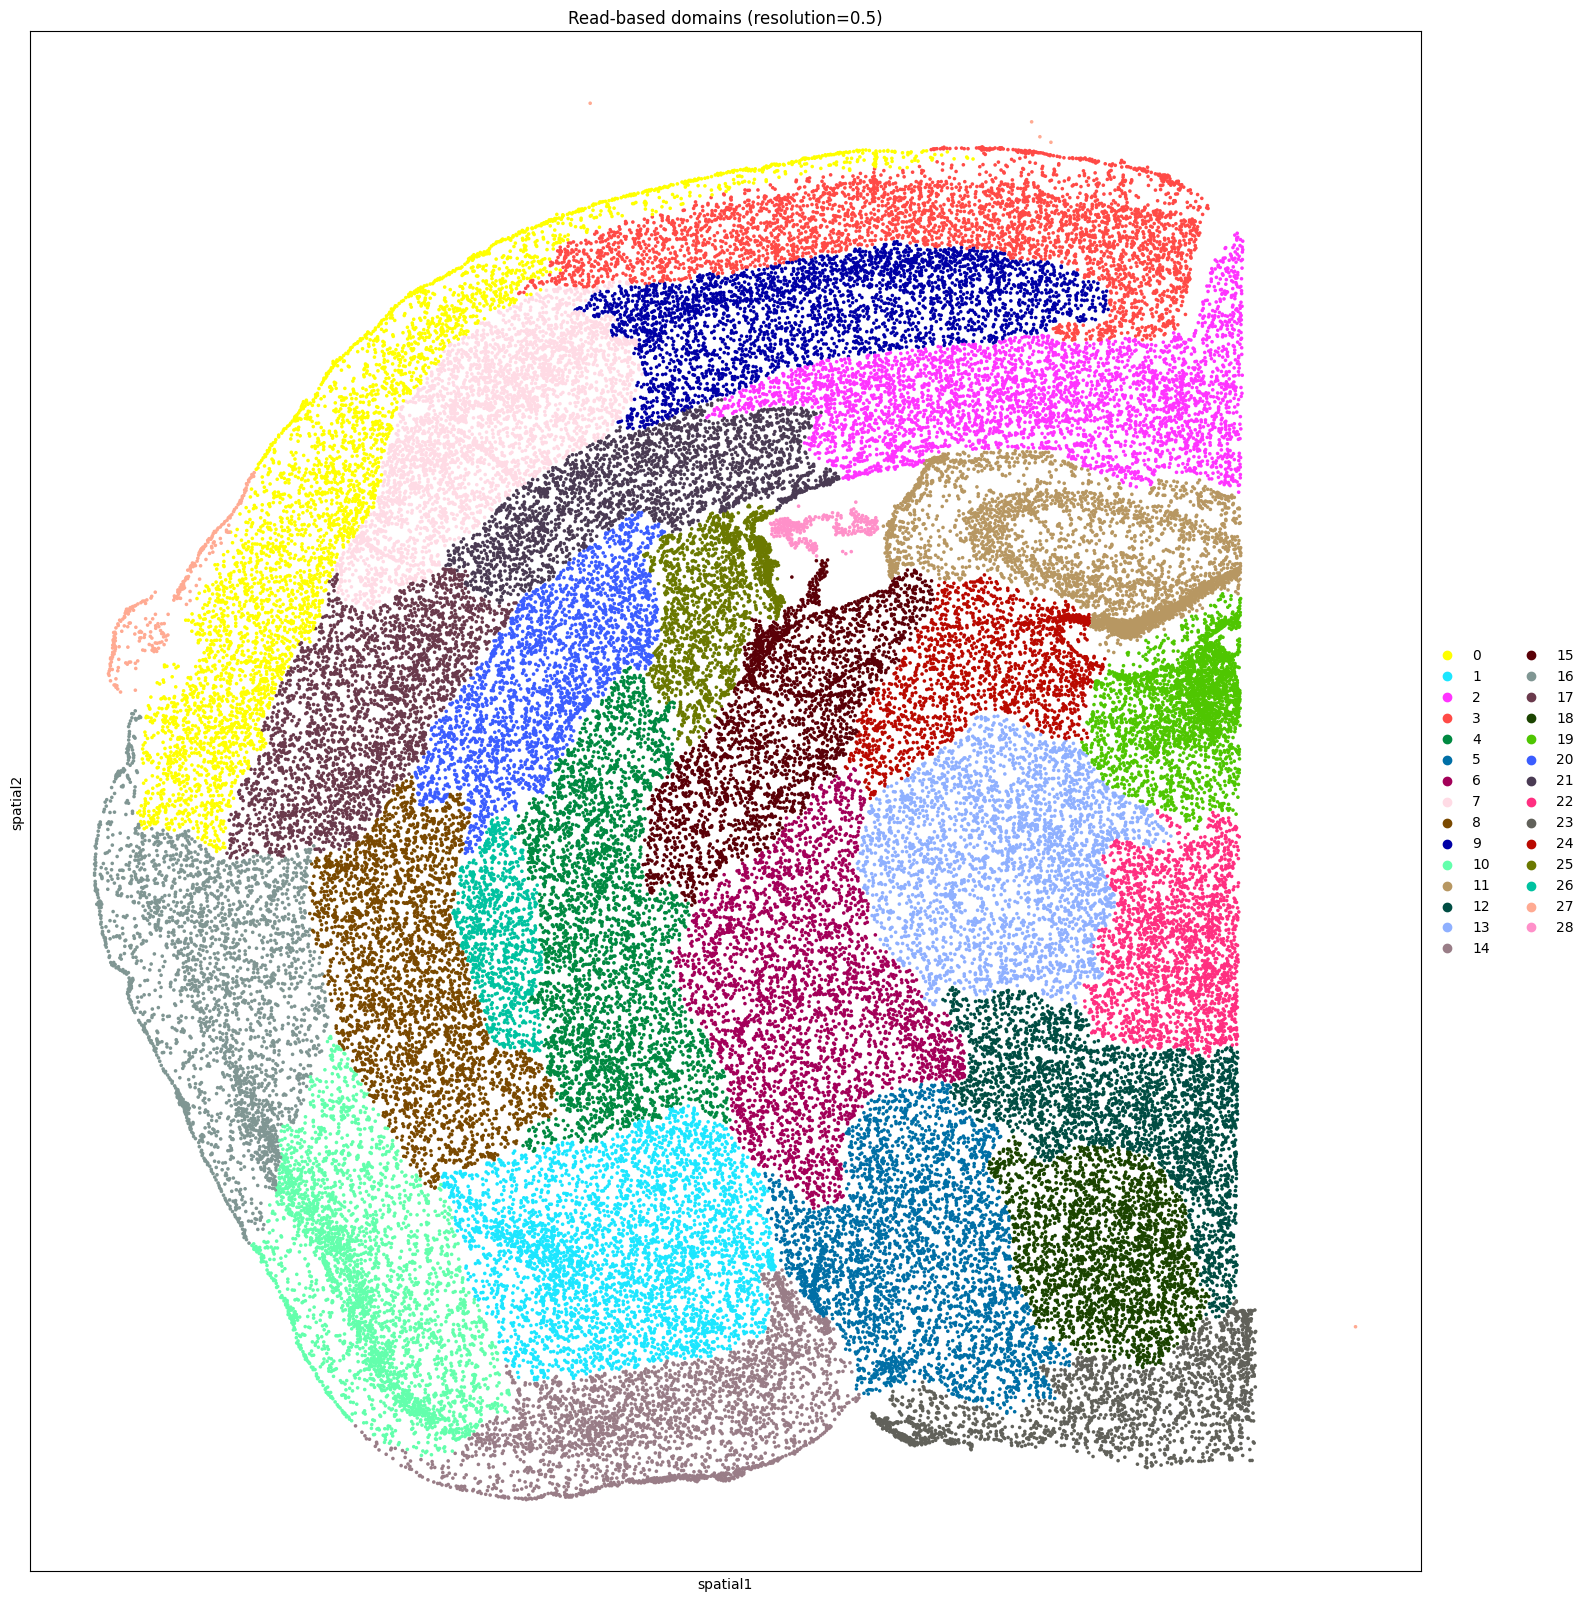

In [16]:
# 5) Plot a spatial map for your favorite resolution:
with plt.rc_context({"figure.figsize": (20, 20)}):
    sc.pl.spatial(
        ad_sn,
        color='local_neighborhood_0.1',
        spot_size=15,
        title="Read-based domains (resolution=0.5)"
    )